In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import entropy, ttest_ind, ttest_1samp
from pathlib import Path
from matplotlib.ticker import FuncFormatter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import MDS
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import kneighbors_graph

import networkx as nx
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# ── Shared Preprocessing ──────────────────────────────────────────
file_path = r"D:\EDI\DATA VISUALIZATION\globalterrorismdb.csv"

df_raw = pd.read_csv(file_path, encoding='latin1', low_memory=False)

# Fill nulls for casualty columns
df_raw['nkill']  = df_raw['nkill'].fillna(0)
df_raw['nwound'] = df_raw['nwound'].fillna(0)

# Derived columns used in Ch3
df_raw['casualties'] = df_raw['nkill'] + df_raw['nwound']
df_raw['decade']     = (df_raw['iyear'] // 10) * 10

# Geo-filtered version for Ch3 map scatter
df_geo = df_raw[
    df_raw['latitude'].between(-90, 90) &
    df_raw['longitude'].between(-180, 180)
].copy()

# Numeric-only clean version for Ch5 (ML/clustering)
_cols = ['iyear','imonth','iday','country','region',
         'latitude','longitude','attacktype1','targtype1','weaptype1','nkill','nwound']
df_clean = df_raw[_cols].dropna()
df_clean = df_clean[(df_clean['longitude'] >= -180) & (df_clean['longitude'] <= 180)]
df_clean = df_clean[df_clean['imonth'] != 0]
df_clean = df_clean[df_clean['iday']   != 0]

print("df_raw  :", df_raw.shape)
print("df_geo  :", df_geo.shape)
print("df_clean:", df_clean.shape)

df_raw  : (181691, 137)
df_geo  : (177133, 137)
df_clean: (176329, 12)


In [3]:
from IPython.display import display, Markdown

display(Markdown("# Chapter 1: Introduction and Describing Data"))

# Chapter 1: Introduction and Describing Data

In [4]:
print(df_raw.shape)
df_raw.head()

(181691, 137)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related,casualties,decade
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,PGIS,0,0,0,0,NaN,1.0,1970
1,1.970000e+11,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,PGIS,0,1,1,1,NaN,0.0,1970
2,1.970010e+11,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,PGIS,-9,-9,1,1,NaN,1.0,1970
3,1.970010e+11,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,PGIS,-9,-9,1,1,NaN,0.0,1970
4,1.970010e+11,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,PGIS,-9,-9,1,1,NaN,0.0,1970


In [5]:
df_raw.info()
df_raw.describe()
df_raw[['iyear','country_txt','region_txt','attacktype1_txt','targtype1_txt']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 137 entries, eventid to decade
dtypes: float64(57), int64(22), object(58)
memory usage: 189.9+ MB


,iyear,country_txt,region_txt,attacktype1_txt,targtype1_txt
0,1970,Dominican Republic,Central America & Caribbean,Assassination,Private Citizens & Property
1,1970,Mexico,North America,Hostage Taking (Kidnapping),Government (Diplomatic)
2,1970,Philippines,Southeast Asia,Assassination,Journalists & Media
3,1970,Greece,Western Europe,Bombing/Explosion,Government (Diplomatic)
4,1970,Japan,East Asia,Facility/Infrastructure Attack,Government (Diplomatic)


In [6]:
df_raw.isnull().sum().sort_values(ascending=False).head(10)

gsubname3           181671
weapsubtype4_txt    181621
weapsubtype4        181621
weaptype4_txt       181618
weaptype4           181618
claimmode3_txt      181558
claimmode3          181558
gsubname2           181531
claim3              181373
guncertain3         181371
dtype: int64

In [7]:
df_raw[['nkill','nwound']].isnull().sum()

nkill     0
nwound    0
dtype: int64

In [8]:
df_raw.dtypes.value_counts()
df_raw['country_txt'].value_counts().head()

country_txt
Iraq           24636
Pakistan       14368
Afghanistan    12731
India          11960
Colombia        8306
Name: count, dtype: int64

In [9]:
print("Mean:", df_raw['nkill'].mean())
print("Median:", df_raw['nkill'].median())
print("Mode:", df_raw['nkill'].mode()[0])
print("Std Dev:", df_raw['nkill'].std())

Mean: 2.2668596683380025
Median: 0.0
Mode: 0.0
Std Dev: 11.227057082478572


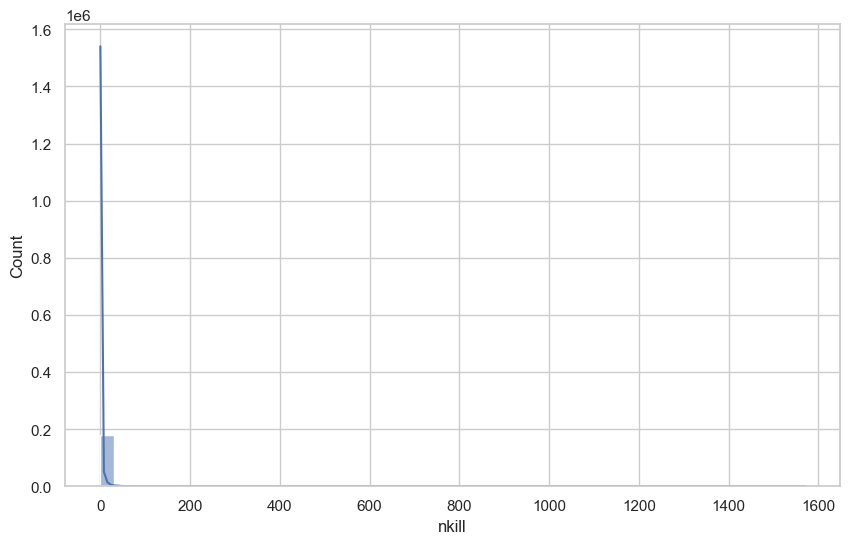

Skewness: 55.66824171046634
Kurtosis: 5887.592622599767


In [10]:
sns.histplot(df_raw['nkill'], bins=50, kde=True)
plt.show()

print("Skewness:", df_raw['nkill'].skew())
print("Kurtosis:", df_raw['nkill'].kurt())

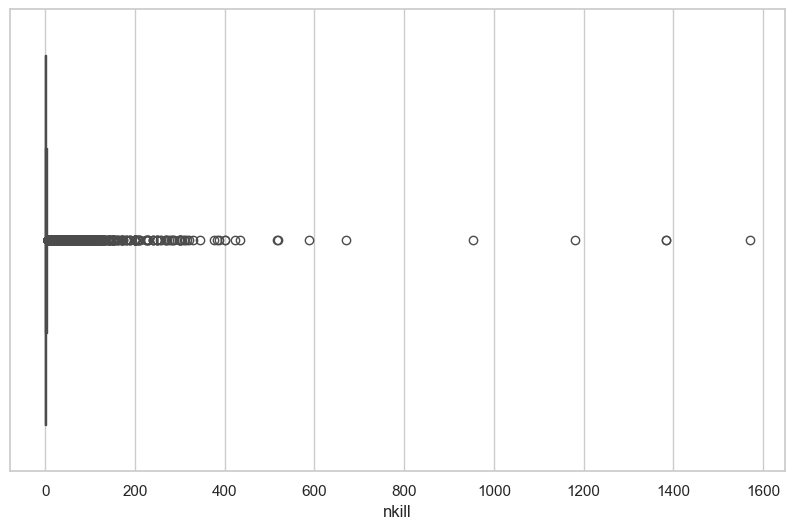

In [11]:
sns.boxplot(x=df_raw['nkill'])
plt.show()

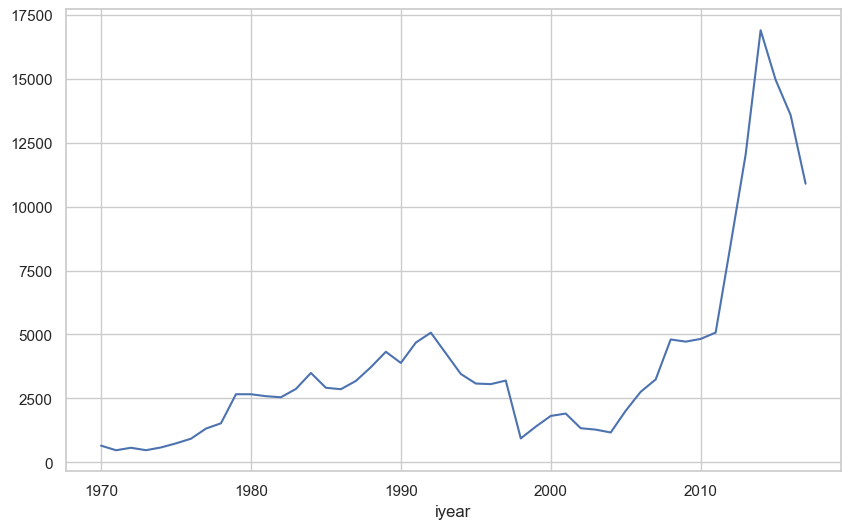

In [12]:
df_raw['iyear'].value_counts().sort_index().plot()
plt.show()

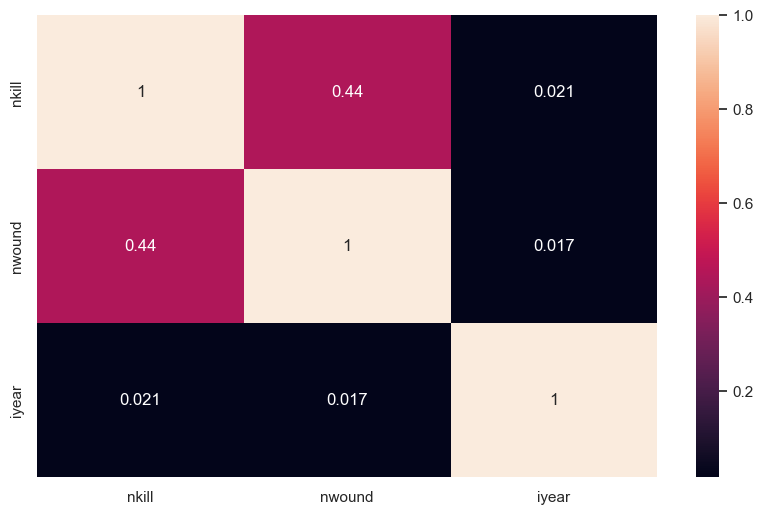

In [14]:
sns.heatmap(df_raw[['nkill','nwound','iyear']].corr(), annot=True)
plt.show()

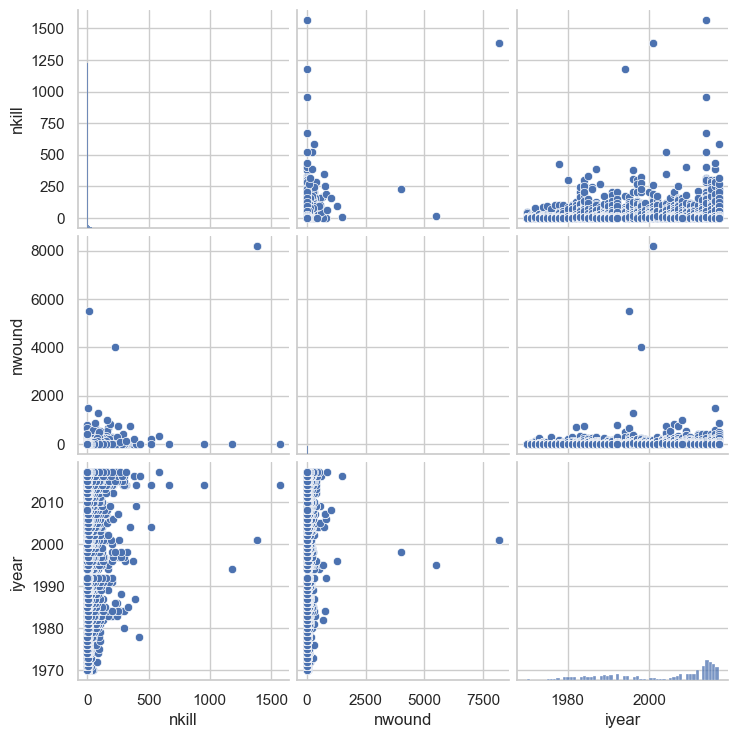

In [15]:
sns.pairplot(df_raw[['nkill','nwound','iyear']])
plt.show()

In [16]:
data = df_raw['nkill']
mean = np.mean(data)
sem = stats.sem(data)
stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)

(np.float64(2.215235840075942), np.float64(2.318483496600063))

In [17]:
stats.ttest_1samp(df_raw['nkill'], popmean=5)


TtestResult(statistic=np.float64(-103.76782352475067), pvalue=np.float64(0.0), df=np.int64(181690))

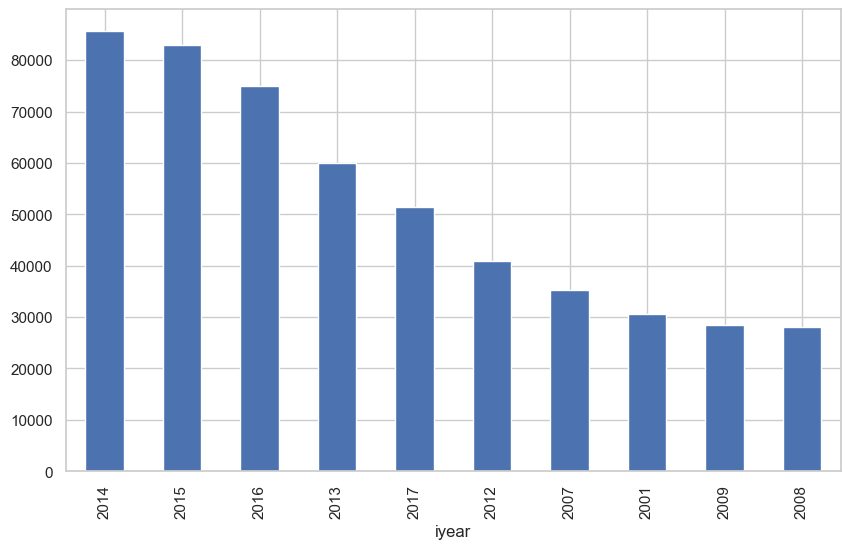

In [18]:
df_raw.groupby('iyear')['casualties'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()

In [19]:
display(Markdown("# Chapter 2: Data Manipulation"))

# Chapter 2: Data Manipulation

In [20]:
df_ch2 = df_raw[['iyear','country_txt','attacktype1_txt','targtype1_txt','weaptype1_txt','nkill','nwound','success']].copy()
df_ch2.dtypes

iyear                int64
country_txt         object
attacktype1_txt     object
targtype1_txt       object
weaptype1_txt       object
nkill              float64
nwound             float64
success              int64
dtype: object

In [21]:
df_ch2[['nkill','nwound']].describe()

,nkill,nwound
count,181691.000000,181691.000000
mean,2.266860,2.883296
std,11.227057,34.309747
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,2.000000,2.000000
max,1570.000000,8191.000000


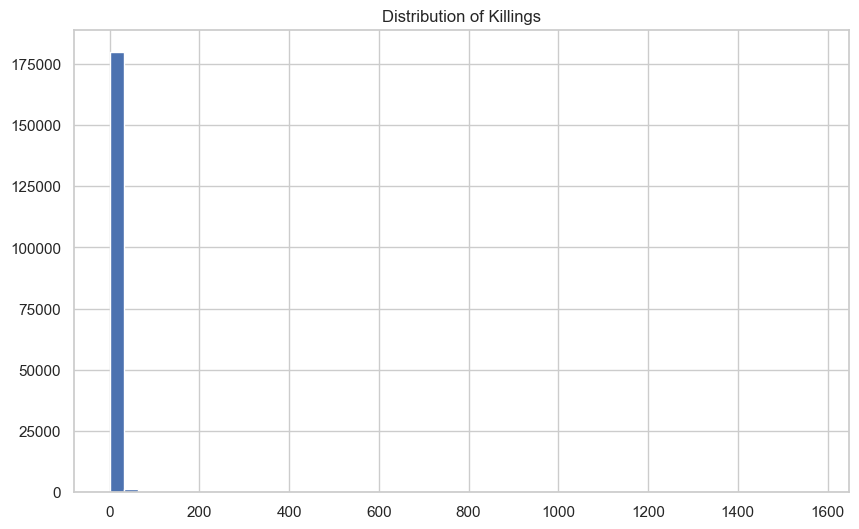

In [22]:
plt.hist(df_ch2['nkill'].dropna(), bins=50)
plt.title("Distribution of Killings")
plt.show()

In [23]:
mean_kill = df_ch2['nkill'].mean()
std_kill = df_ch2['nkill'].std()
n = df_ch2['nkill'].count()

ci_lower = mean_kill - 1.96*(std_kill/np.sqrt(n))
ci_upper = mean_kill + 1.96*(std_kill/np.sqrt(n))

(ci_lower, ci_upper)

(np.float64(2.2152352353674125), np.float64(2.3184841013085924))

In [24]:
success = df_ch2[df_ch2['success']==1]['nkill'].dropna()
fail = df_ch2[df_ch2['success']==0]['nkill'].dropna()

ttest_ind(success, fail)

TtestResult(statistic=np.float64(21.176241870161817), pvalue=np.float64(2.0873613070856505e-99), df=np.float64(181689.0))

In [25]:
df_ch2.isnull().sum()

iyear              0
country_txt        0
attacktype1_txt    0
targtype1_txt      0
weaptype1_txt      0
nkill              0
nwound             0
success            0
dtype: int64

In [26]:
df_ch2.iloc[0:5]
df_ch2.loc[df_ch2['country_txt']=="India"]

,iyear,country_txt,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound,success
1186,1972,India,Hijacking,Airports & Aircraft,Explosives,0.0,0.0,1
2764,1975,India,Bombing/Explosion,Government (General),Explosives,4.0,0.0,1
3857,1976,India,Bombing/Explosion,Airports & Aircraft,Explosives,0.0,0.0,1
5327,1977,India,Hijacking,Airports & Aircraft,Firearms,0.0,0.0,1
7337,1979,India,Armed Assault,Police,Firearms,0.0,0.0,1
...,...,...,...,...,...,...,...,...
181663,2017,India,Bombing/Explosion,Police,Explosives,0.0,0.0,1
181665,2017,India,Facility/Infrastructure Attack,Business,Firearms,0.0,0.0,1
181672,2017,India,Armed Assault,Police,Explosives,8.0,3.0,1
181684,2017,India,Hostage Taking (Kidnapping),Government (General),Firearms,0.0,0.0,1


In [27]:
country_counts = df_ch2.groupby('country_txt')['nkill'].sum().reset_index()
df_ch2.groupby('attacktype1_txt')['nkill'].sum().sort_values(ascending=False)

pivot = pd.pivot_table(df_ch2, values='nkill', index='iyear', columns='attacktype1_txt', aggfunc='sum')
pivot.head()

attacktype1_txt,Armed Assault,Assassination,Bombing/Explosion,Facility/Infrastructure Attack,Hijacking,Hostage Taking (Barricade Incident),Hostage Taking (Kidnapping),Unarmed Assault,Unknown
iyear,,,,,,,,,
1970,36.0,18.0,96.0,9.0,1.0,0.0,10.0,0.0,4.0
1971,14.0,73.0,79.0,1.0,0.0,0.0,2.0,NaN,4.0
1972,58.0,208.0,281.0,1.0,5.0,0.0,12.0,NaN,1.0
1973,41.0,171.0,75.0,0.0,34.0,38.0,11.0,0.0,0.0
1974,34.0,161.0,286.0,0.0,1.0,35.0,14.0,1.0,7.0


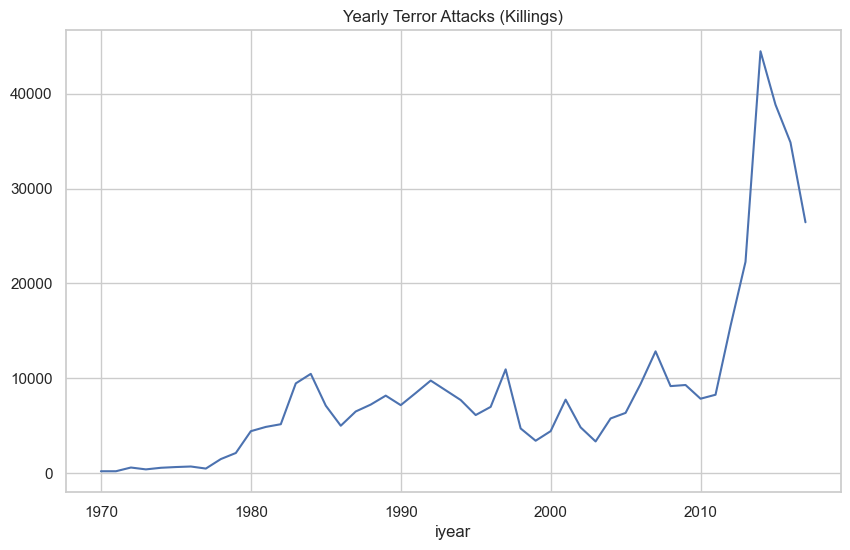

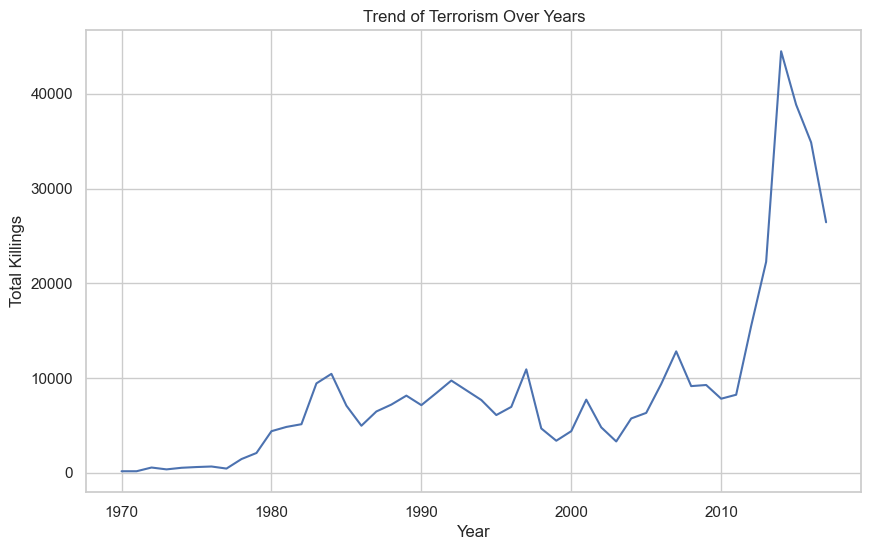

In [28]:
yearly = df_ch2.groupby('iyear')['nkill'].sum()

yearly.plot()
plt.title("Yearly Terror Attacks (Killings)")
plt.show()

plt.plot(yearly)
plt.xlabel("Year")
plt.ylabel("Total Killings")
plt.title("Trend of Terrorism Over Years")
plt.show()

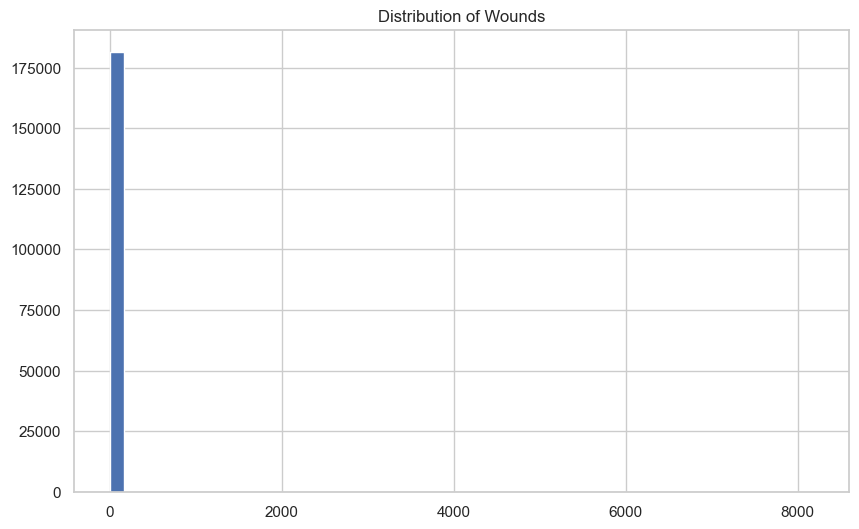

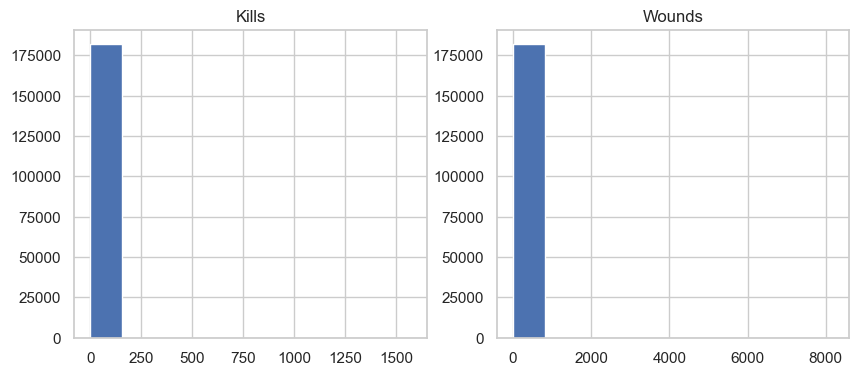

In [29]:
plt.hist(df_ch2['nwound'], bins=50)
plt.title("Distribution of Wounds")
plt.show()

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].hist(df_ch2['nkill'])
ax[0].set_title("Kills")

ax[1].hist(df_ch2['nwound'])
ax[1].set_title("Wounds")

plt.show()

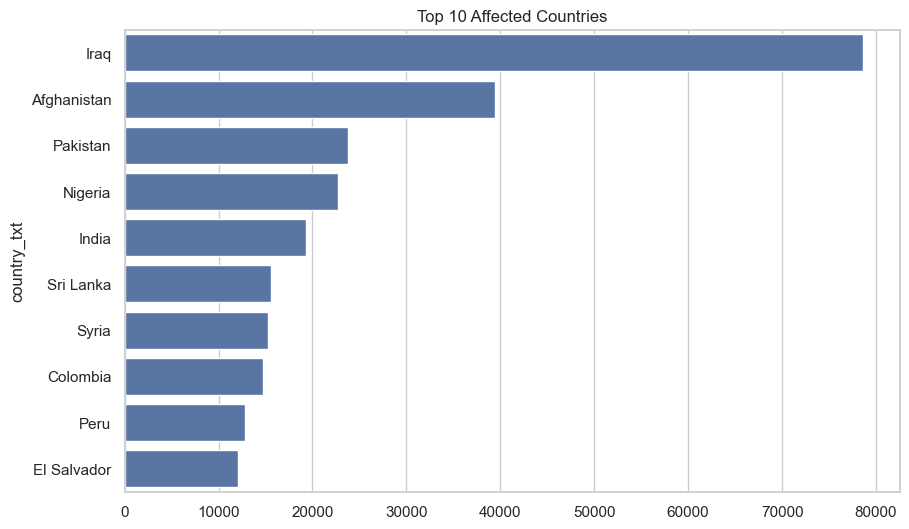

In [30]:
top_countries = df_ch2.groupby('country_txt')['nkill'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Affected Countries")
plt.show()

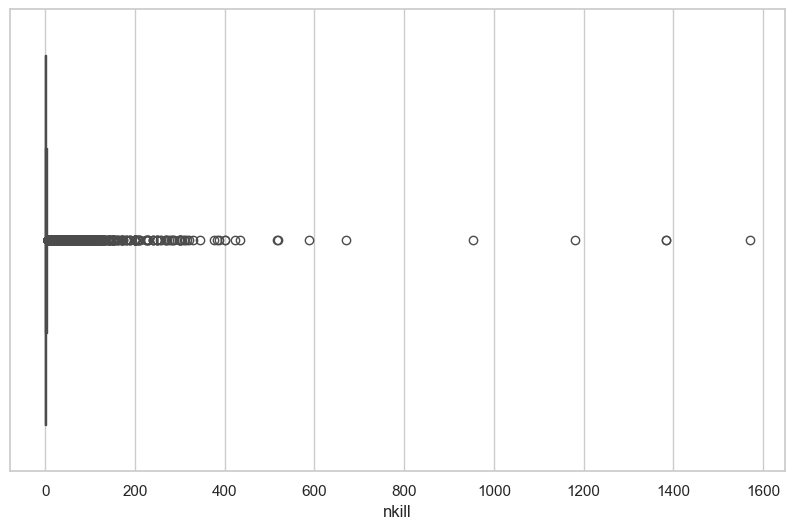

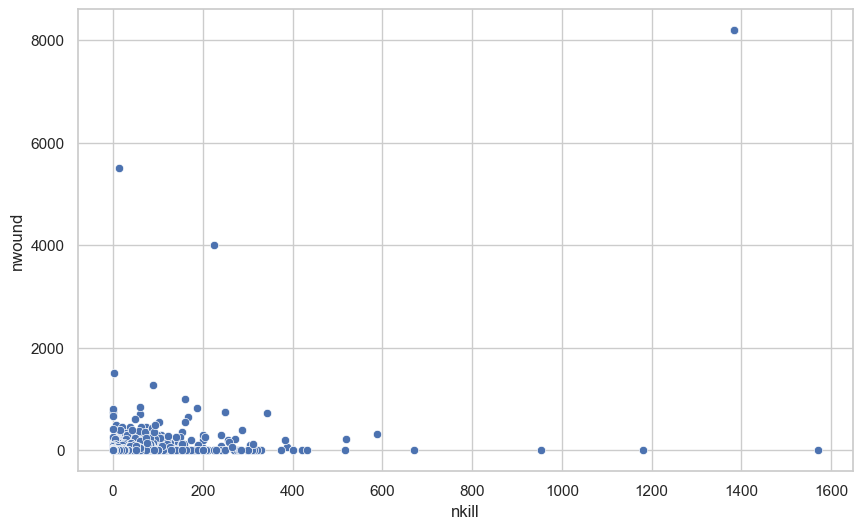

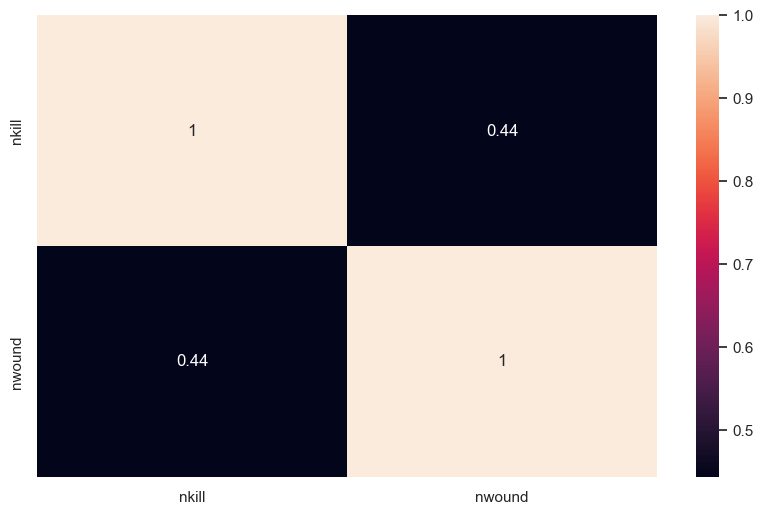

In [31]:
sns.boxplot(x=df_ch2['nkill'])
plt.show()

sns.scatterplot(x='nkill', y='nwound', data=df_ch2)
plt.show()

corr = df_ch2[['nkill','nwound']].corr()
sns.heatmap(corr, annot=True)
plt.show()

In [32]:
X = df_ch2[['nkill','nwound']].fillna(0)

kmeans = KMeans(n_clusters=3)
df_ch2['cluster'] = kmeans.fit_predict(X)

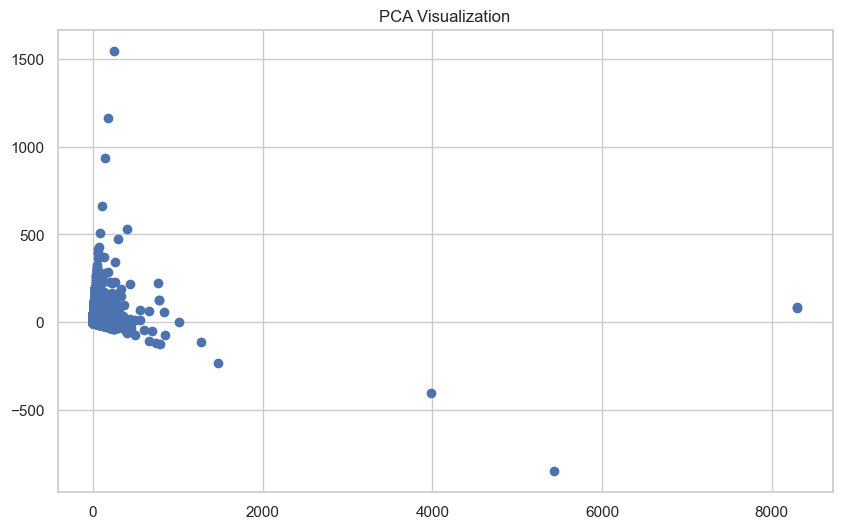

In [33]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X)

plt.scatter(reduced[:,0], reduced[:,1])
plt.title("PCA Visualization")
plt.show()

In [34]:
df_ch2.groupby('weaptype1_txt')['nkill'].sum().sort_values(ascending=False).head(10)

weaptype1_txt
Firearms                                                                       174894.0
Explosives                                                                     174277.0
Unknown                                                                         42620.0
Melee                                                                           10575.0
Incendiary                                                                       5476.0
Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)      3184.0
Chemical                                                                          624.0
Other                                                                             123.0
Sabotage Equipment                                                                 83.0
Biological                                                                          9.0
Name: nkill, dtype: float64

In [35]:
display(Markdown("# Chapter 3:  Data Visualization"))

# Chapter 3:  Data Visualization

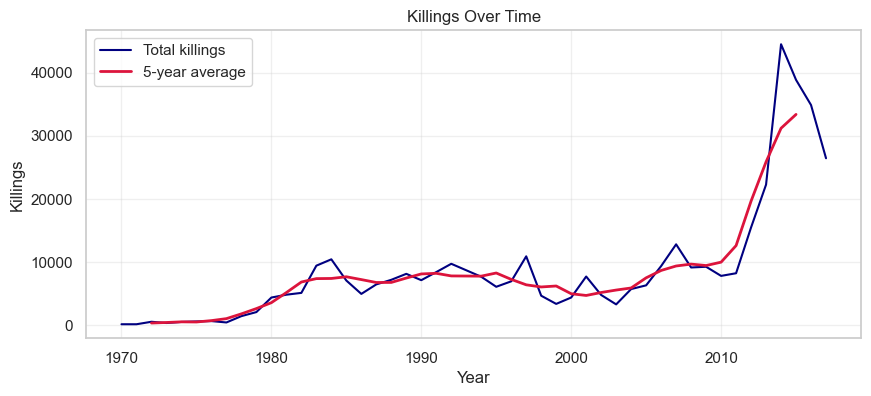

In [39]:
yearly_killings = df_raw.groupby("iyear")["nkill"].sum()
rolling_killings = yearly_killings.rolling(5, center=True).mean()

plt.figure(figsize=(10, 4))
plt.plot(yearly_killings.index, yearly_killings.values, label="Total killings", color="navy")
plt.plot(rolling_killings.index, rolling_killings.values, label="5-year average", color="crimson", linewidth=2)
plt.title("Killings Over Time")
plt.xlabel("Year")
plt.ylabel("Killings")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

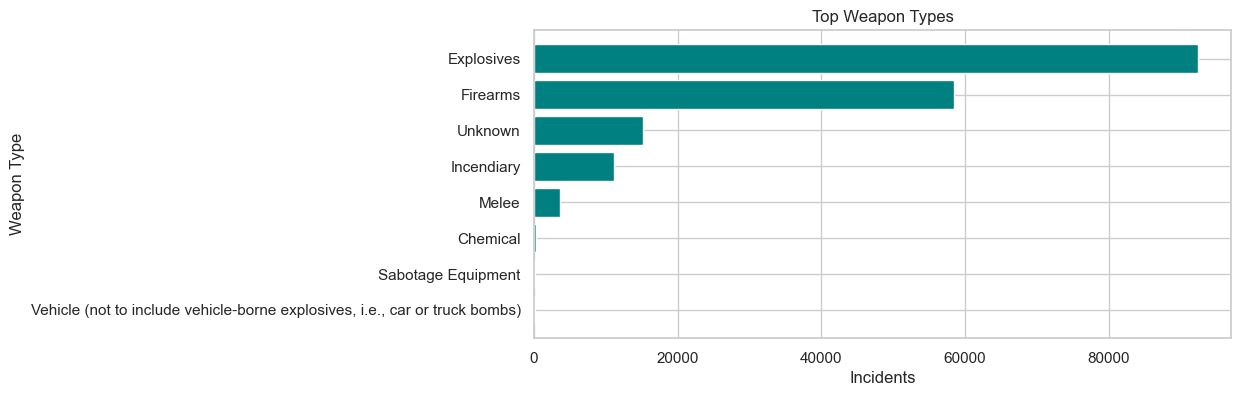

In [40]:
weapon_counts = df_raw["weaptype1_txt"].value_counts().head(8).sort_values()

plt.figure(figsize=(9, 4))
plt.barh(weapon_counts.index, weapon_counts.values, color="teal")
plt.title("Top Weapon Types")
plt.xlabel("Incidents")
plt.ylabel("Weapon Type")
plt.show()

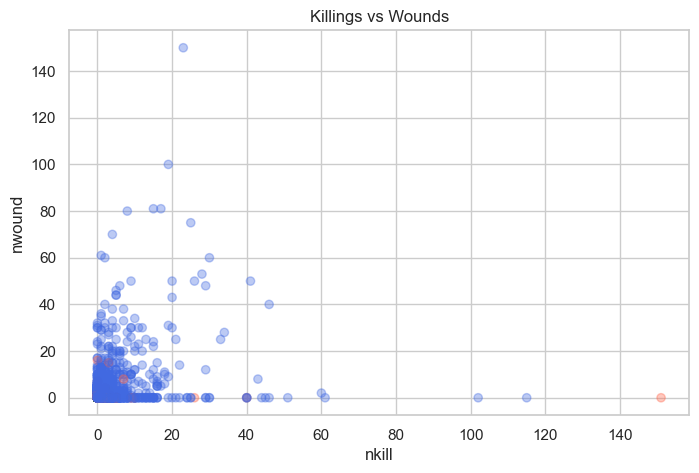

In [41]:
sample_mv = df_raw[["nkill", "nwound", "success"]].sample(2500, random_state=42)
colors = sample_mv["success"].map({0: "tomato", 1: "royalblue"})

plt.figure(figsize=(8, 5))
plt.scatter(sample_mv["nkill"], sample_mv["nwound"], c=colors, alpha=0.35)
plt.title("Killings vs Wounds")
plt.xlabel("nkill")
plt.ylabel("nwound")
plt.show()

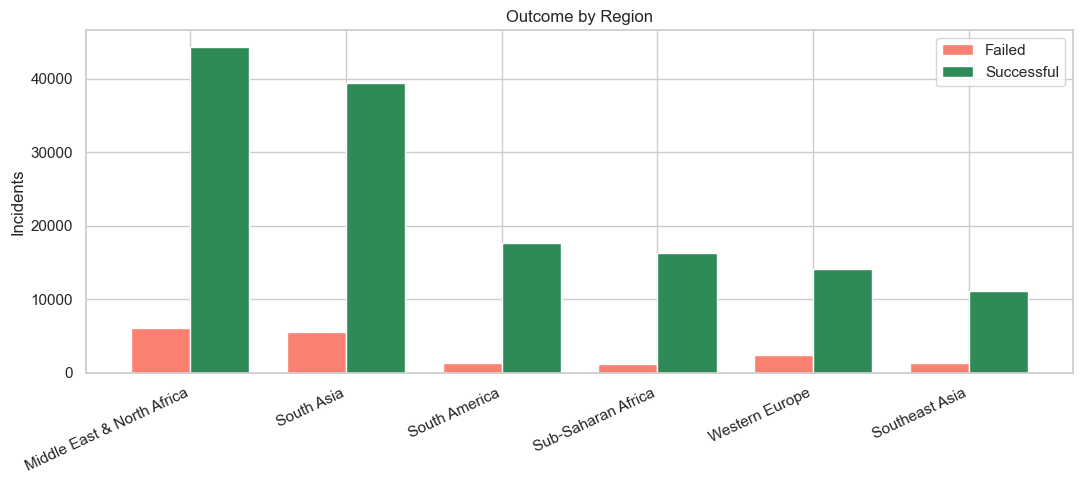

In [42]:
region_success = pd.crosstab(df_raw["region_txt"], df_raw["success"])
region_success = region_success.loc[df_raw["region_txt"].value_counts().head(6).index]

x = np.arange(len(region_success.index))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, region_success.get(0, pd.Series(0, index=region_success.index)), width, label="Failed", color="salmon")
plt.bar(x + width/2, region_success.get(1, pd.Series(0, index=region_success.index)), width, label="Successful", color="seagreen")
plt.xticks(x, region_success.index, rotation=25, ha="right")
plt.title("Outcome by Region")
plt.ylabel("Incidents")
plt.legend()
plt.tight_layout()
plt.show()

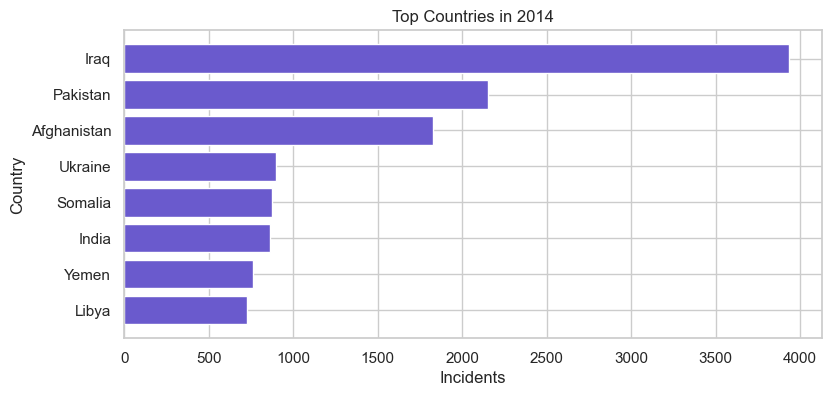

In [43]:
selected_year = 2014
country_year = df_raw[df_raw["iyear"] == selected_year]["country_txt"].value_counts().head(8).sort_values()

plt.figure(figsize=(9, 4))
plt.barh(country_year.index, country_year.values, color="slateblue")
plt.title(f"Top Countries in {selected_year}")
plt.xlabel("Incidents")
plt.ylabel("Country")
plt.show()

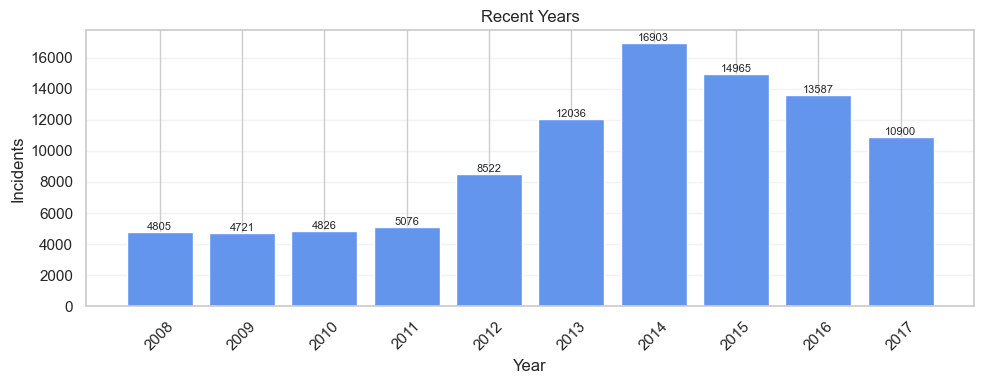

In [44]:
plt.figure(figsize=(10, 4))
bars = plt.bar(yearly_incidents.tail(10).index.astype(str), yearly_incidents.tail(10).values, color="cornflowerblue")
plt.title("Recent Years")
plt.xlabel("Year")
plt.ylabel("Incidents")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), int(bar.get_height()), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
+

plt.show()

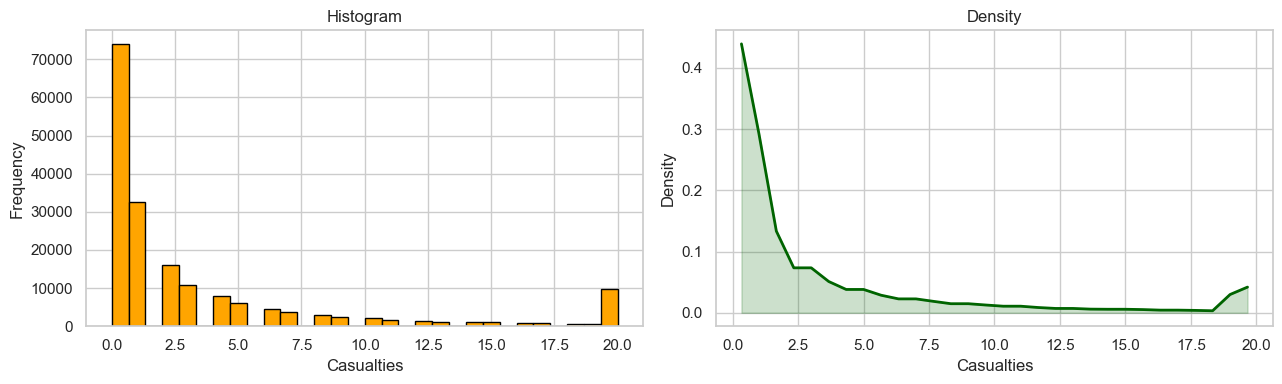

In [47]:
casualty_clip = df_raw["casualties"].clip(upper=df_raw["casualties"].quantile(0.95))
counts, bins = np.histogram(casualty_clip, bins=30, density=True)
centers = (bins[:-1] + bins[1:]) / 2
smooth = pd.Series(counts).rolling(3, center=True, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(casualty_clip, bins=30, color="orange", edgecolor="black")
axes[0].set_title("Histogram")
axes[0].set_xlabel("Casualties")
axes[0].set_ylabel("Frequency")

axes[1].plot(centers, smooth, color="darkgreen", linewidth=2)
axes[1].fill_between(centers, smooth, color="darkgreen", alpha=0.2)
axes[1].set_title("Density")
axes[1].set_xlabel("Casualties")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

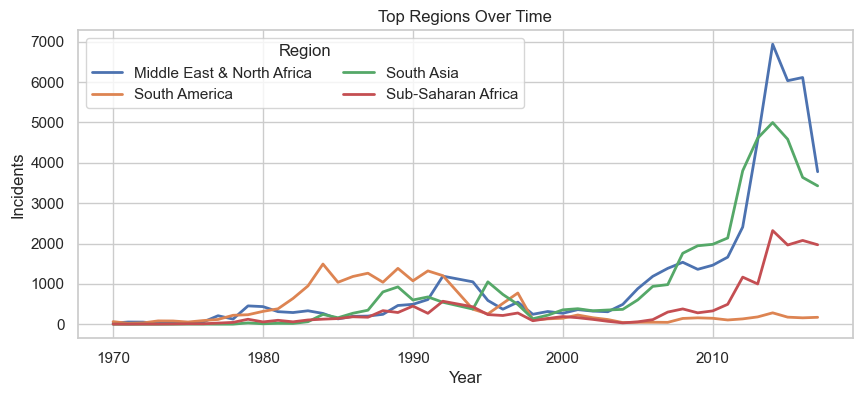

In [48]:
legend_regions = df_raw["region_txt"].value_counts().head(4).index
legend_data = (
    df_raw[df_raw["region_txt"].isin(legend_regions)]
      .groupby(["iyear", "region_txt"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(10, 4))
for region in legend_data.columns:
    plt.plot(legend_data.index, legend_data[region], label=region, linewidth=2)

plt.title("Top Regions Over Time")
plt.xlabel("Year")
plt.ylabel("Incidents")
plt.legend(title="Region", frameon=True, ncol=2)
plt.show()

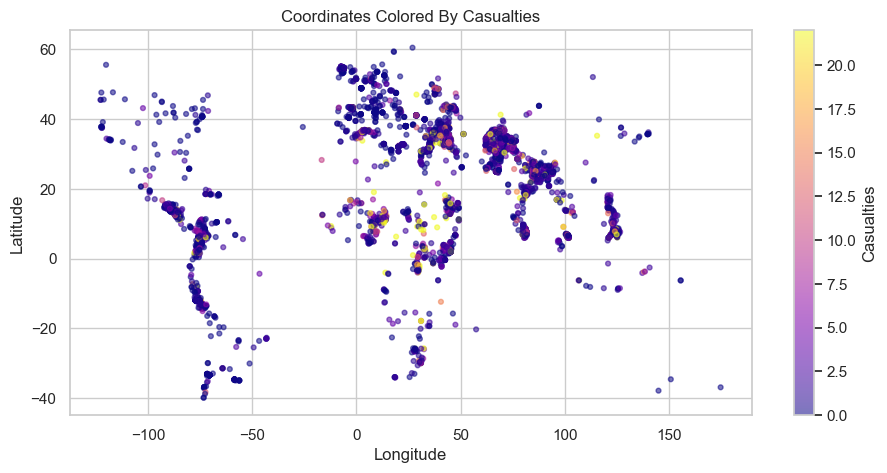

In [49]:
geo_sample = df_geo.sample(min(5000, len(df_geo)), random_state=3)

plt.figure(figsize=(11, 5))
sc = plt.scatter(
    geo_sample["longitude"],
    geo_sample["latitude"],
    c=geo_sample["casualties"].clip(upper=geo_sample["casualties"].quantile(0.95)),
    cmap="plasma",
    s=12,
    alpha=0.55,
)
cb = plt.colorbar(sc)
cb.set_label("Casualties")
plt.title("Coordinates Colored By Casualties")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

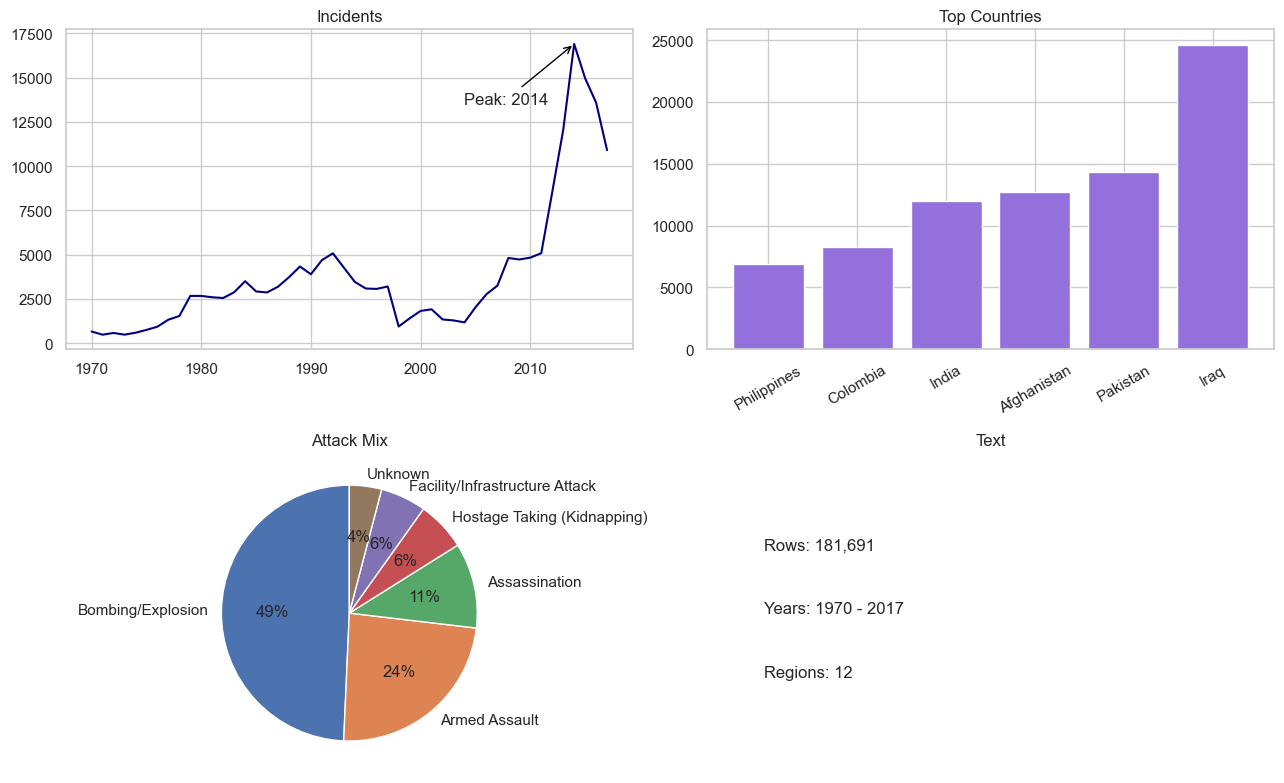

In [50]:
peak_year = yearly_incidents.idxmax()
peak_value = yearly_incidents.max()
attack_mix = df_raw["attacktype1_txt"].value_counts().head(6)
country_mix = df_raw["country_txt"].value_counts().head(6).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(yearly_incidents.index, yearly_incidents.values, color="navy")
axes[0, 0].annotate(
    f"Peak: {peak_year}",
    xy=(peak_year, peak_value),
    xytext=(peak_year - 10, peak_value * 0.8),
    arrowprops=dict(arrowstyle="->", color="black"),
)
axes[0, 0].set_title("Incidents")

axes[0, 1].bar(country_mix.index, country_mix.values, color="mediumpurple")
axes[0, 1].set_title("Top Countries")
axes[0, 1].tick_params(axis="x", rotation=30)

axes[1, 0].pie(attack_mix.values, labels=attack_mix.index, autopct="%1.0f%%", startangle=90)
axes[1, 0].set_title("Attack Mix")

axes[1, 1].text(0.1, 0.7, f"Rows: {len(df_raw):,}")
axes[1, 1].text(0.1, 0.5, f"Years: {df_raw['iyear'].min()} - {df_raw['iyear'].max()}")
axes[1, 1].text(0.1, 0.3, f"Regions: {df_raw['region_txt'].nunique()}")
axes[1, 1].set_title("Text")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [52]:
display(Markdown("# Chapter 4:  Visualization Using Seaborn"))

# Chapter 4:  Visualization Using Seaborn

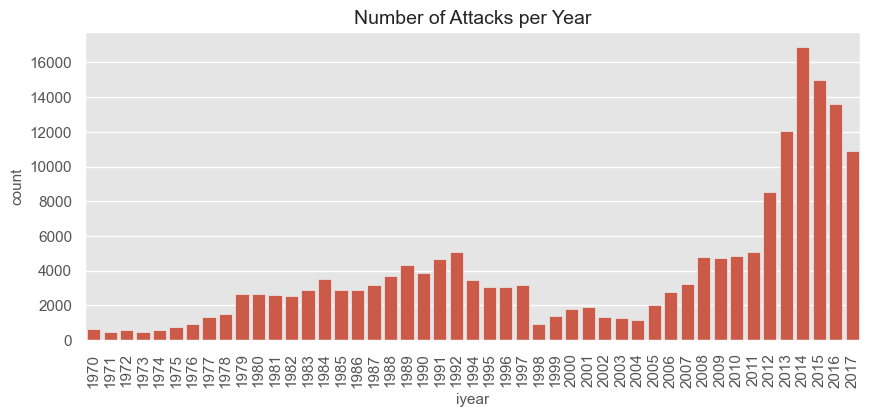

In [53]:
sns.countplot(x='iyear', data=df_raw)
plt.xticks(rotation=90)
plt.title("Number of Attacks per Year")
plt.show()

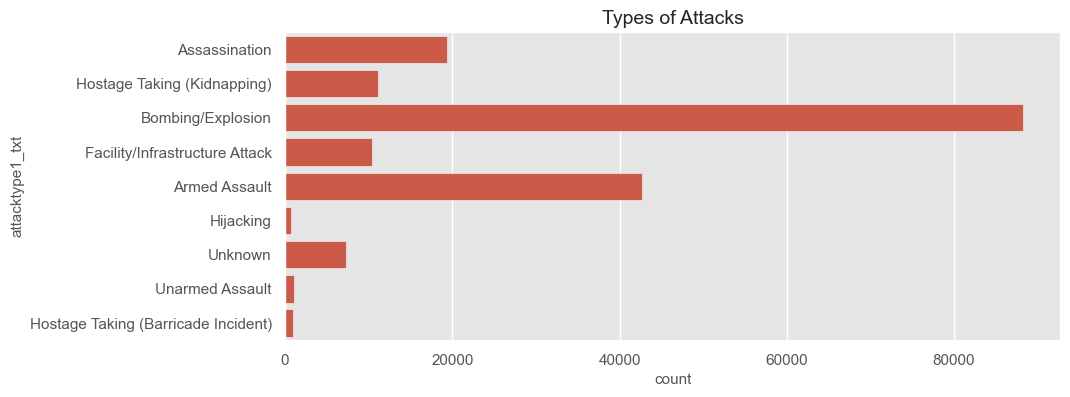

In [55]:
sns.countplot(y='attacktype1_txt', data=df_raw)
plt.title("Types of Attacks")
plt.show()

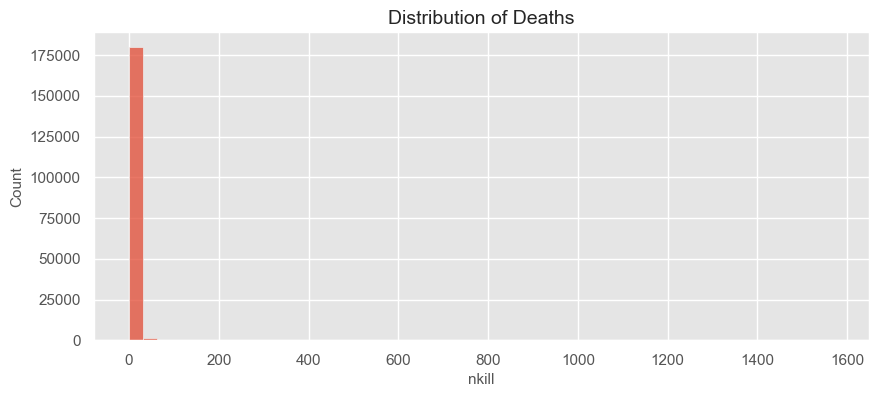

In [56]:
sns.histplot(df_raw['nkill'].dropna(), bins=50)
plt.title("Distribution of Deaths")
plt.show()

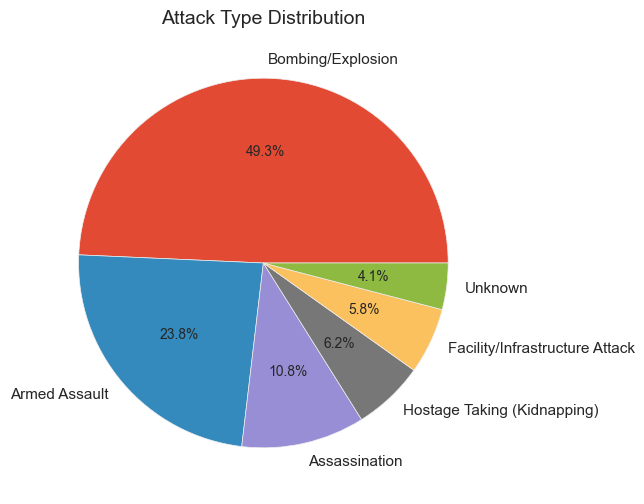

In [58]:
attack_counts = df_raw['attacktype1_txt'].value_counts().head(6)

plt.figure(figsize=(6,6))
plt.pie(attack_counts, labels=attack_counts.index, autopct='%1.1f%%')
plt.title("Attack Type Distribution")
plt.show()

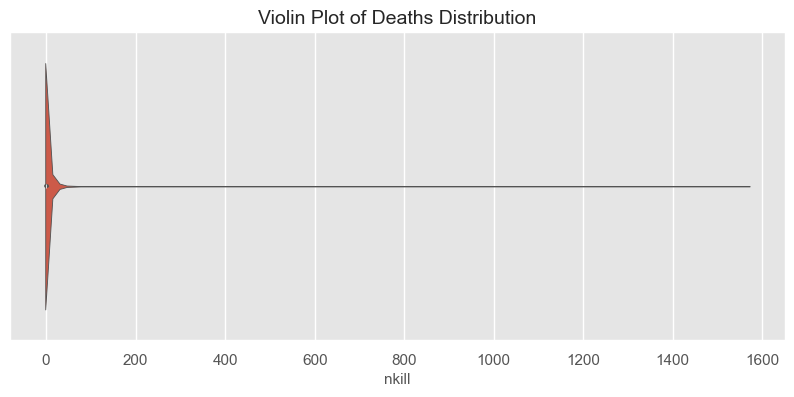

In [61]:
sns.violinplot(x=df_raw['nkill'])
plt.title("Violin Plot of Deaths Distribution")
plt.show()

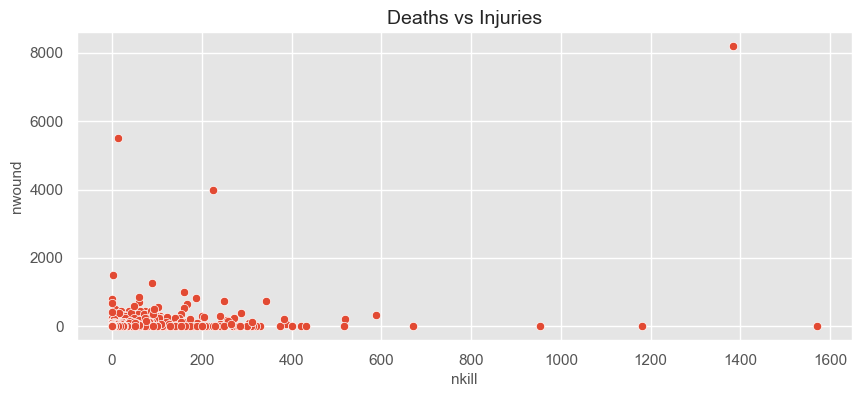

In [62]:
sns.scatterplot(x='nkill', y='nwound', data=df_raw)
plt.title("Deaths vs Injuries")
plt.show()

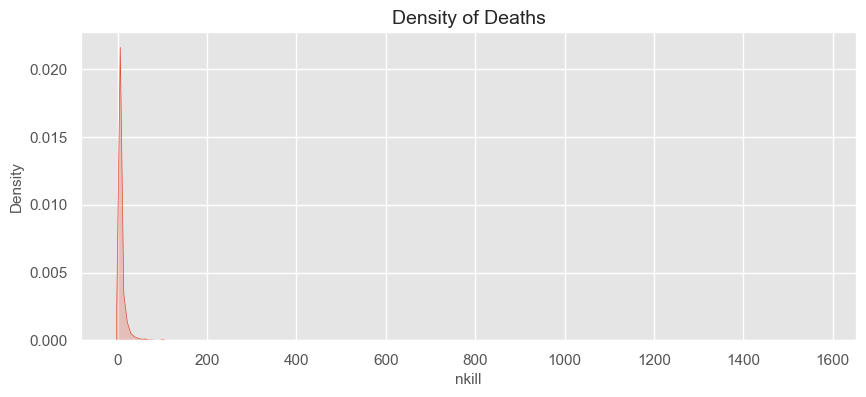

In [63]:
sns.kdeplot(df_raw['nkill'].dropna(), fill=True)
plt.title("Density of Deaths")
plt.show()

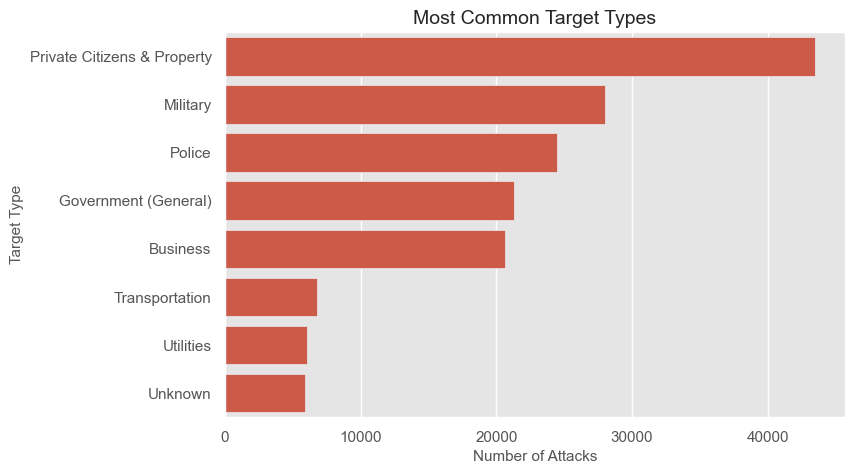

In [64]:
# Shows who is most targeted:
# civilians
# military
# government
targets = df_raw['targtype1_txt'].value_counts().head(8)

plt.figure(figsize=(8,5))
sns.barplot(x=targets.values, y=targets.index)

plt.title("Most Common Target Types")
plt.xlabel("Number of Attacks")
plt.ylabel("Target Type")
plt.show()

In [65]:
!pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Fix renderer
pio.renderers.default = "browser"

# Load dataset
df = pd.read_csv("globalterrorismdb.csv", encoding='latin1', low_memory=False)

# Clean data
df_geo = df.dropna(subset=['latitude', 'longitude'])

# Take sample (important for performance)
df_sample = df_geo.sample(3000, random_state=42)

# Map plot
fig = px.scatter_geo(
    df_sample,
    lat='latitude',
    lon='longitude',
    color='region_txt',
    hover_name='country_txt',
    title="Global Terrorism Attacks Map"
)

fig.show()

In [63]:
fig = px.density_mapbox(
    df_sample,
    lat='latitude',
    lon='longitude',
    radius=5,
    center=dict(lat=20, lon=0),
    zoom=1,
    mapbox_style="carto-positron",
    title="Terrorism Hotspots (Density Map)"
)

fig.show()

# Chapter 5:   Information visualization

In [3]:
# Describing Shape and Head 
print(df_clean.shape)
df_clean.head()

(176329, 12)


,iyear,imonth,iday,country,region,latitude,longitude,attacktype1,targtype1,weaptype1,nkill,nwound
0,1970,7,2,58,2,18.456792,-69.951164,1,14,13,1.0,0.0
5,1970,1,1,217,1,37.005105,-89.176269,2,3,5,0.0,0.0
6,1970,1,2,218,3,-34.891151,-56.187214,1,3,5,0.0,0.0
7,1970,1,2,217,1,37.791927,-122.225906,3,21,6,0.0,0.0
8,1970,1,2,217,1,43.076592,-89.412488,7,4,8,0.0,0.0


               iyear         imonth           iday        country  \
count  176329.000000  176329.000000  176329.000000  176329.000000   
mean     2002.974576       6.468584      15.588684     132.359187   
std        13.182986       3.387010       8.765917     113.132914   
min      1970.000000       1.000000       1.000000       4.000000   
25%      1991.000000       4.000000       8.000000      78.000000   
50%      2009.000000       6.000000      15.000000      98.000000   
75%      2014.000000       9.000000      23.000000     160.000000   
max      2017.000000      12.000000      31.000000    1004.000000   

              region       latitude      longitude    attacktype1  \
count  176329.000000  176329.000000  176329.000000  176329.000000   
mean        7.196173      23.503784      27.966365       3.239802   
std         2.910809      18.556497      57.735908       1.902646   
min         1.000000     -53.154613    -176.176447       1.000000   
25%         6.000000      11.5441

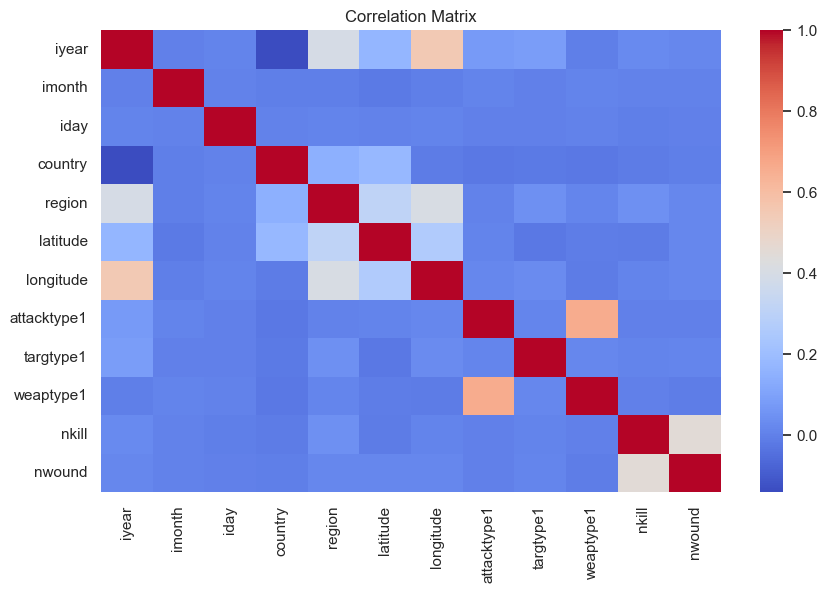

In [4]:
# describe the data and correlation heatmap (which features move together)
print(df_clean.describe())

plt.figure(figsize=(10,6))
sns.heatmap(df_clean.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [5]:
# sanity recheck - did the preprocessing ruin anything 

print(df_clean.shape)
df_clean.describe()

(176329, 12)


,iyear,imonth,iday,country,region,latitude,longitude,attacktype1,targtype1,weaptype1,nkill,nwound
count,176329.000000,176329.000000,176329.000000,176329.000000,176329.000000,176329.000000,176329.000000,176329.000000,176329.000000,176329.000000,176329.000000,176329.000000
mean,2002.974576,6.468584,15.588684,132.359187,7.196173,23.503784,27.966365,3.239802,8.420107,6.425682,2.235599,2.922038
std,13.182986,3.387010,8.765917,113.132914,2.910809,18.556497,57.735908,1.902646,6.642523,2.136553,11.193256,34.801845
min,1970.000000,1.000000,1.000000,4.000000,1.000000,-53.154613,-176.176447,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1991.000000,4.000000,8.000000,78.000000,6.000000,11.544192,4.895168,2.000000,3.000000,5.000000,0.000000,0.000000
50%,2009.000000,6.000000,15.000000,98.000000,7.000000,31.467463,43.294178,3.000000,4.000000,6.000000,0.000000,0.000000
75%,2014.000000,9.000000,23.000000,160.000000,10.000000,34.667808,68.715498,3.000000,14.000000,6.000000,2.000000,2.000000
max,2017.000000,12.000000,31.000000,1004.000000,12.000000,74.633553,179.366667,9.000000,22.000000,13.000000,1570.000000,8191.000000


In [6]:
# Computing the entropy of each column (useful for feature selection)
entropy_dict = {}

for col in df_clean.columns:
    counts = df_clean[col].value_counts()
    ent = entropy(counts)
    entropy_dict[col] = ent
    print(f"{col}: {ent}")

iyear: 3.4608490065350317
imonth: 2.483030696399276
iday: 3.4287553850249926
country: 3.6555548104718136
region: 1.9494217377999825
latitude: 8.598986842222955
longitude: 8.587774059400807
attacktype1: 1.4624587975685568
targtype1: 2.328941346975764
weaptype1: 1.1882608002015178
nkill: 1.6640229916052844
nwound: 1.5834285323924633


In [7]:
# scaling for PCA Kmeans MDS ICA

X = df_clean.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Explained Variance: [0.17433446 0.13867535]


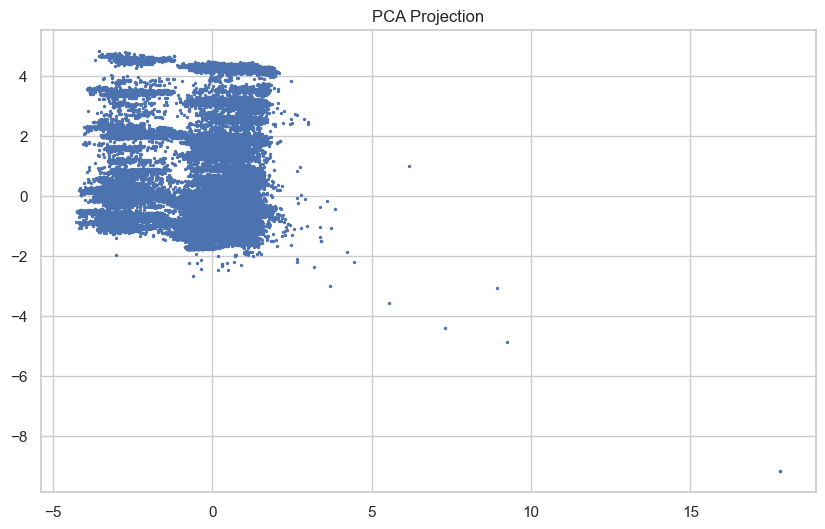

In [15]:
# Principal Component Analysis 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

plt.scatter(X_pca[:,0], X_pca[:,1], s=2)
plt.title("PCA Projection")
plt.show()

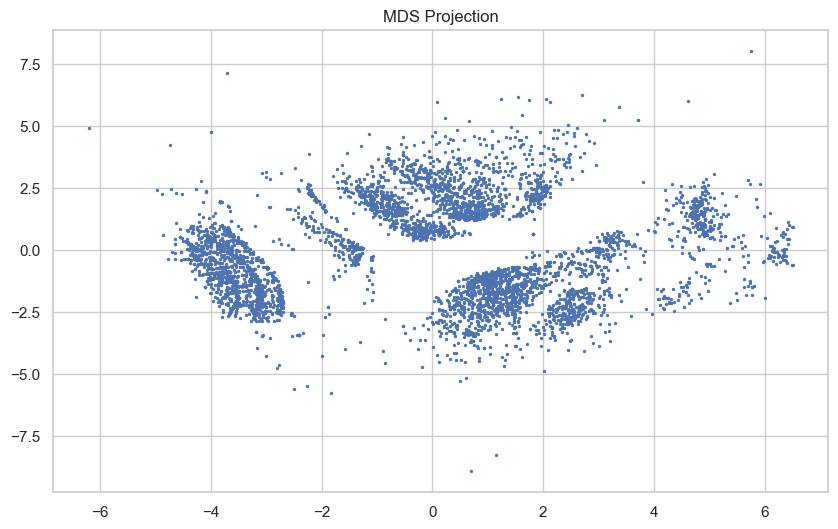

In [13]:
# multli dimensional Scaling 

X_small = X_scaled[:5000]

mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_small)

plt.scatter(X_mds[:,0], X_mds[:,1], s=2)
plt.title("MDS Projection")
plt.show()

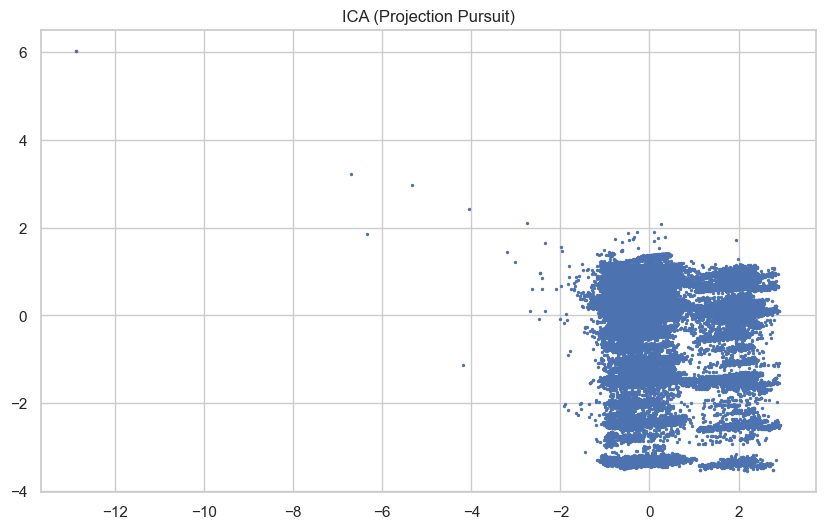

In [8]:
# independent Component Analysis 
ica = FastICA(n_components=2, random_state=42)
X_ica = ica.fit_transform(X_scaled)

plt.scatter(X_ica[:,0], X_ica[:,1], s=2)
plt.title("ICA (Projection Pursuit)")
plt.show()

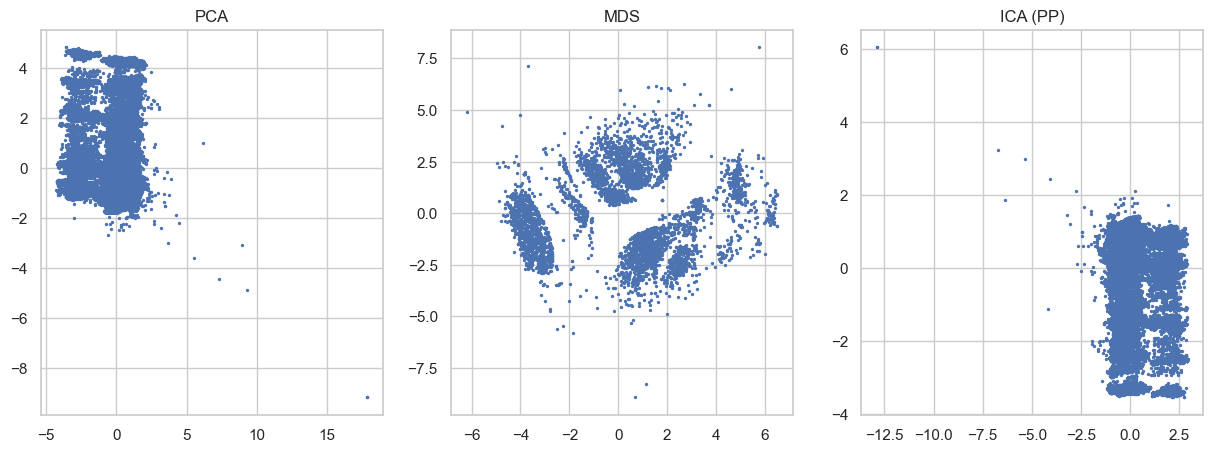

In [17]:
# Side-by-side comparison
'''
PCA → variance structure
MDS → distance structure
ICA → independence structure

'''
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], s=2)
plt.title("PCA")

plt.subplot(1,3,2)
plt.scatter(X_mds[:,0], X_mds[:,1], s=2)
plt.title("MDS")

plt.subplot(1,3,3)
plt.scatter(X_ica[:,0], X_ica[:,1], s=2)
plt.title("ICA (PP)")

plt.show()

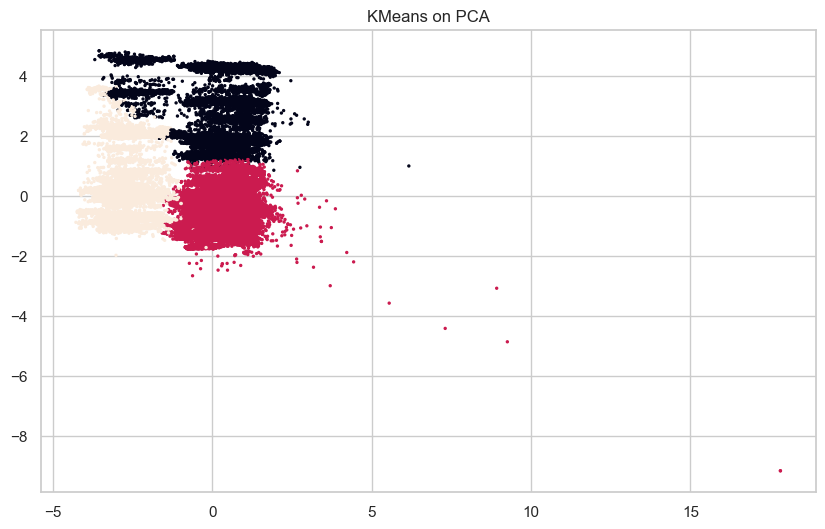

In [18]:
# KMeans on PCA space

kmeans = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca, s=2)
plt.title("KMeans on PCA")
plt.show()

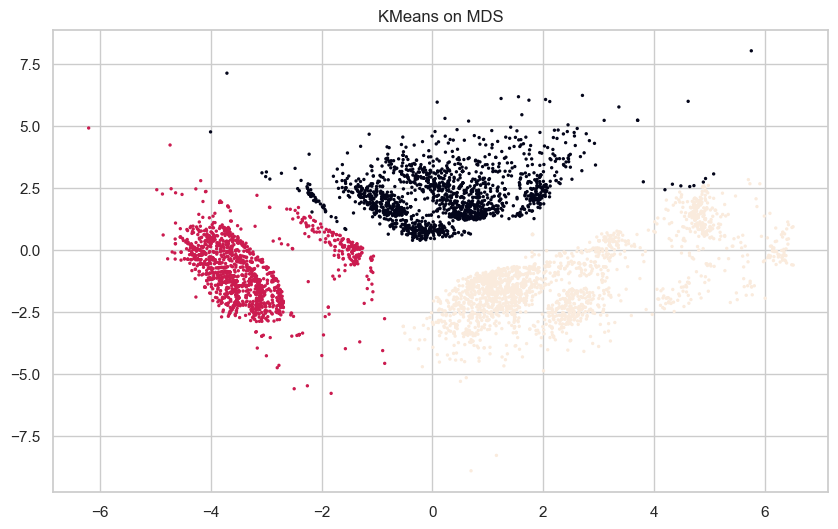

In [19]:
# KMeans on MDS

kmeans_mds = KMeans(n_clusters=3, random_state=42)
labels_mds = kmeans_mds.fit_predict(X_mds)

plt.scatter(X_mds[:,0], X_mds[:,1], c=labels_mds, s=2)
plt.title("KMeans on MDS")
plt.show()

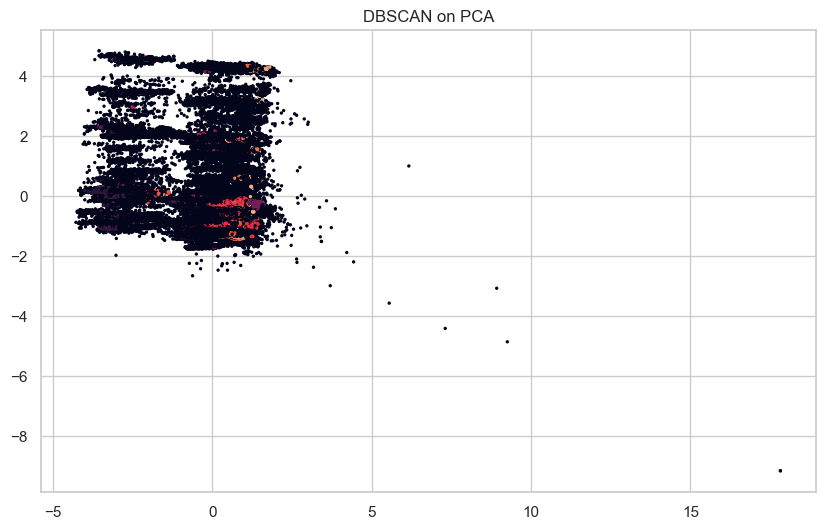

In [20]:
# DBSCAN on PCA 

dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_db = dbscan.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db, s=2)
plt.title("DBSCAN on PCA")
plt.show()

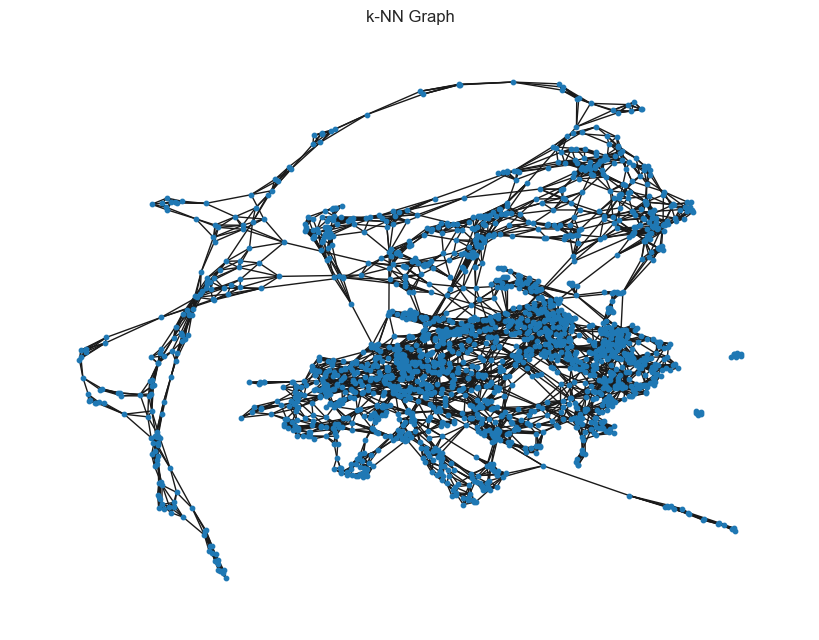

In [22]:
# KNN Network Graph using network x

X_small = X_scaled[:2000]

graph = kneighbors_graph(X_small, n_neighbors=5)
G = nx.from_scipy_sparse_array(graph)

plt.figure(figsize=(8,6))
nx.draw(G, node_size=10)
plt.title("k-NN Graph")
plt.show()

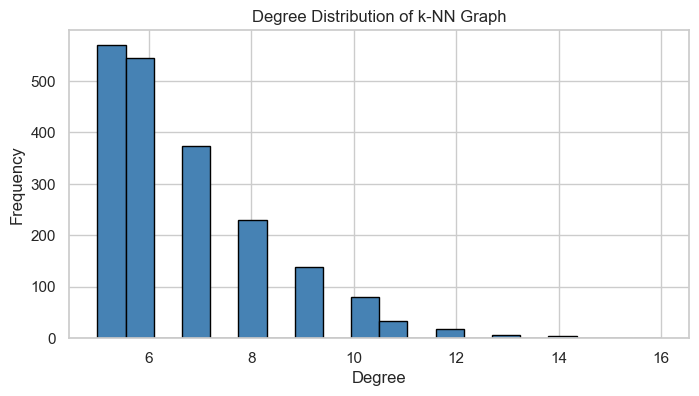

In [28]:
# Degree Distribution of k-NN Graph
degrees = [d for _, d in G.degree()]

plt.figure(figsize=(8, 4))
plt.hist(degrees, bins=20, color='steelblue', edgecolor='black')
plt.title("Degree Distribution of k-NN Graph")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

In [25]:
import folium
from folium.plugins import HeatMap

geo_sample = df_geo[['latitude', 'longitude', 'casualties']].dropna().sample(10000, random_state=42)

# Base map
m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB dark_matter')

# Heatmap layer
heat_data = [[row['latitude'], row['longitude']] for _, row in geo_sample.iterrows()]
HeatMap(heat_data, radius=4, blur=3, min_opacity=0.3).add_to(m)

# Display
m